In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tarp

from typing import Tuple, List, Optional


In [2]:
class PosteriorPlots():

    def __init__(self,  batch_size: int = 1_000, only_last: bool = True ):
        super().__init__()
        self.savedir = './logs/OdisseoSimulatorFullAttentionAggregation/'
        self.batch_size = batch_size
        self.labels = ['$t_{end}$', '$M_{plummer}$', '$M_{NFW}$', '$M_{MN}$']
        self.observation_idx = [i for i in range(100)]
        self.num_total_samples = 100
        self.only_last = only_last
        
    def __call__(self,):
        return self._call()

    def _call(self,  ):


        true_theta_test_set = np.zeros((len(self.observation_idx), 4))
        predicted_theta_test_set = np.zeros((self.num_total_samples, len(self.observation_idx), 4))

        old_true_theta_test_set = np.load(f"{self.savedir}/pictures/predicted_theta_test_set.npz")['true_theta']
        old_predicted_theta_test_set = np.load(f"{self.savedir}/pictures/predicted_theta_test_set.npz")['predicted_theta']

        print(f'Plotting for n_observation:', len(old_predicted_theta_test_set))

        rank_plot = self._plot_ranks_histogram(
                samples=old_predicted_theta_test_set,
                trues=old_true_theta_test_set,
                nbins=10)
        plt.show()
        
        coverage_plot = self._plot_coverage(
            samples=old_predicted_theta_test_set,
            trues=old_true_theta_test_set,
            plotscatter=True,
        )
        plt.show()

        prediction_plot = self._plot_predictions(
            samples=old_predicted_theta_test_set,
            trues=old_true_theta_test_set,
        )
        plt.show()

        tarp_plot = self._plot_TARP(
            posterior_samples=old_predicted_theta_test_set,
            theta=old_true_theta_test_set,
        )
        plt.show()
            

        predicted_theta_test_set = np.load(f"{self.savedir}/pictures/predicted_theta_test_set_100.npz")['predicted_theta']
        true_theta_test_set = np.load(f"{self.savedir}/pictures/predicted_theta_test_set_100.npz")['true_theta']

        predicted_theta_test_set, true_theta_test_set = self.filter_zero_observations(
            predicted_theta_test_set, true_theta_test_set
        )

        if self.only_last:

            old_predicted_theta_test_set = np.concatenate(
                [old_predicted_theta_test_set, predicted_theta_test_set], axis=1
            )
            old_true_theta_test_set = np.concatenate(
                [old_true_theta_test_set, true_theta_test_set], axis=0
            )

            print('Plotting for n_observation:', len(old_true_theta_test_set))

            rank_plot = self._plot_ranks_histogram(
                samples=old_predicted_theta_test_set,
                trues=old_true_theta_test_set,
                nbins=10)
            plt.show()
            
            coverage_plot = self._plot_coverage(
                samples=old_predicted_theta_test_set,
                trues=old_true_theta_test_set,
                plotscatter=True,
            )
            plt.show()

            prediction_plot = self._plot_predictions(
                samples=old_predicted_theta_test_set,
                trues=old_true_theta_test_set,
            )
            plt.show()

            tarp_plot = self._plot_TARP(
                posterior_samples=old_predicted_theta_test_set,
                theta=old_true_theta_test_set,
            )
            plt.show()


        else:
            for i in range(len(true_theta_test_set)):

                print(f'Plotting for n_observation:', len(old_predicted_theta_test_set)+i)

                old_predicted_theta_test_set = np.concatenate(
                    [old_predicted_theta_test_set, predicted_theta_test_set[:, :i]], axis=1
                )
                old_true_theta_test_set = np.concatenate(
                    [old_true_theta_test_set, true_theta_test_set[:i]], axis=0
                )
                

                rank_plot = self._plot_ranks_histogram(
                    samples=old_predicted_theta_test_set,
                    trues=old_true_theta_test_set,
                    nbins=10)
                plt.show()
                
                coverage_plot = self._plot_coverage(
                    samples=old_predicted_theta_test_set,
                    trues=old_true_theta_test_set,
                    plotscatter=True,
                )
                plt.show()

                prediction_plot = self._plot_predictions(
                    samples=old_predicted_theta_test_set,
                    trues=old_true_theta_test_set,
                )
                plt.show()

                tarp_plot = self._plot_TARP(
                    posterior_samples=old_predicted_theta_test_set,
                    theta=old_true_theta_test_set,
                )
                plt.show()
            
    
    def _get_ranks(
            self,
            samples: np.array,
            trues: np.array,
        ) -> np.array:
            """Get the marginal ranks of the true parameters in the posterior samples.

            Args:
                samples (np.array): posterior samples of shape (nsamples, ndata, npars)
                trues (np.array): true parameters of shape (ndata, npars)

            Returns:
                np.array: ranks of the true parameters in the posterior samples 
                    of shape (ndata, npars)
            """
            ranks = (samples < trues[None, ...]).sum(axis=0)
            return ranks


    def _plot_ranks_histogram(
            self, samples: np.ndarray, trues: np.ndarray, nbins: int = 10
        ) -> plt.Figure:
            """
            Plot a histogram of ranks for each parameter.

            Args:
                samples (numpy.ndarray): List of samples.
                trues (numpy.ndarray): Array of true values.
                signature (str): Signature for the histogram file name.
                nbins (int, optional): Number of bins for the histogram. Defaults to 10.

            Returns:
                matplotlib.figure.Figure: The generated figure.

            """
            ndata, npars = trues.shape
            navg = ndata / nbins
            ranks = self._get_ranks(samples, trues)

            fig, ax = plt.subplots(1, npars, figsize=(npars * 3, 4))
            if npars == 1:
                ax = [ax]

            for i in range(npars):
                ax[i].hist(np.array(ranks)[:, i], bins=nbins)
                ax[i].set_title(self.labels[i])
            ax[0].set_ylabel('counts')

            for axis in ax:
                axis.set_xlim(0, ranks.max())
                axis.set_xlabel('rank')
                axis.grid(visible=True)
                axis.axhline(navg, color='k')
                axis.axhline(navg - navg ** 0.5, color='k', ls="--")
                axis.axhline(navg + navg ** 0.5, color='k', ls="--")
            return fig

    def _plot_coverage(
            self, samples: np.ndarray, trues: np.ndarray, plotscatter: bool = True
        ) -> plt.Figure:
            """
            Plot the coverage of predicted percentiles against empirical percentiles.

            Args:
                samples (numpy.ndarray): Array of predicted samples.
                trues (numpy.ndarray): Array of true values.
                signature (str): Signature for the plot file name.
                plotscatter (bool, optional): Whether to plot the scatter plot. Defaults to True.

            Returns:
                matplotlib.figure.Figure: The generated figure.

            """
            ndata, npars = trues.shape
            ranks = self._get_ranks(samples, trues)

            unicov = [np.sort(np.random.uniform(0, 1, ndata)) for j in range(200)]
            unip = np.percentile(unicov, [5, 16, 84, 95], axis=0)

            fig, ax = plt.subplots(1, npars, figsize=(npars * 4, 4))
            if npars == 1:
                ax = [ax]
            cdf = np.linspace(0, 1, len(ranks))
            for i in range(npars):
                xr = np.sort(ranks[:, i])
                xr = xr / xr[-1]
                ax[i].plot(cdf, cdf, 'k--')
                if plotscatter:
                    ax[i].fill_between(cdf, unip[0], unip[-1],
                                    color='gray', alpha=0.2)
                    ax[i].fill_between(cdf, unip[1], unip[-2],
                                    color='gray', alpha=0.4)
                ax[i].plot(xr, cdf, lw=2, label='posterior')
                ax[i].set(adjustable='box', aspect='equal')
                ax[i].set_title(self.labels[i])
                ax[i].set_xlabel('Predicted Percentile')
                ax[i].set_xlim(0, 1)
                ax[i].set_ylim(0, 1)

            ax[0].set_ylabel('Empirical Percentile')
            for axis in ax:
                axis.grid(visible=True)
            return fig

    def _plot_predictions(
            self, samples: np.ndarray, trues: np.ndarray,
        ) -> plt.Figure:
            """
            Plot the mean and standard deviation of the predicted samples against
            the true values.

            Args:
                samples (np.ndarray): Array of predicted samples.
                trues (np.ndarray): Array of true values.
                signature (str): Signature for the plot.

            Returns:
                plt.Figure: The plotted figure.
            """
            npars = trues.shape[-1]
            mus, stds = samples.mean(axis=0), samples.std(axis=0)
            # print(f"mus shape: {mus.shape}, stds shape: {stds.shape}, trues shape: {trues.shape}")
            fig, axs = plt.subplots(1, npars, figsize=(npars * 5, 4))
            if npars == 1:
                axs = [axs]
            else:
                axs = axs.flatten()
            for j in range(npars):
                axs[j].errorbar(trues[:, j], mus[:, j], stds[:, j],
                                fmt="none", elinewidth=0.5, alpha=0.5)
                axs[j].plot(
                    *(2 * [np.linspace(min(trues[:, j]), max(trues[:, j]), 10)]),
                    'k--', ms=0.2, lw=0.5)
                axs[j].grid(which='both', lw=0.5)
                axs[j].set(adjustable='box', )
                axs[j].set_title(self.labels[j], fontsize=12)
                axs[j].set_xlabel('True')
            axs[0].set_ylabel('Predicted')

            return fig
    def _plot_TARP(
        self, posterior_samples: np.array, theta: np.array,
        references: str = "random", metric: str = "euclidean",
        bootstrap: Optional[bool] = True, norm: Optional[bool] = True,
        num_alpha_bins: Optional[int] = 10,
        num_bootstrap: Optional[int] = 100
    ) -> plt.Figure:
        """
        Plots the TARP credibility metric for the given posterior samples
        and theta values. See https://arxiv.org/abs/2302.03026 for details.

        Args:
            posterior_samples (np.array): Array of posterior samples.
            theta (np.array): Array of theta values.
            signature (str): Signature for the plot.
            references (str, optional): TARP reference type for TARP calculation. 
                Defaults to "random".
            metric (str, optional): TARP distance metric for TARP calculation. 
                Defaults to "euclidean".
            bootstrap (bool, optional): Whether to use bootstrapping for TARP error bars. 
                Defaults to False.
            norm (bool, optional): Whether to normalize the TARP metric. Defaults to True.
            num_alpha_bins (int, optional):number of bins to use for the TARP
                credibility values. Defaults to None.
            num_bootstrap (int, optional): Number of bootstrap iterations
                for TARP calculation. Defaults to 100.

        Returns:
            plt.Figure: The generated TARP plot.
        """
        ecp, alpha = tarp.get_tarp_coverage(
            posterior_samples, theta,
            references=references, metric=metric,
            norm=norm, bootstrap=bootstrap,
            num_alpha_bins=num_alpha_bins,
            num_bootstrap=num_bootstrap
        )

        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        ax.plot([0, 1], [0, 1], ls='--', color='k')
        if bootstrap:
            ecp_mean = np.mean(ecp, axis=0)
            ecp_std = np.std(ecp, axis=0)
            ax.plot(alpha, ecp_mean, label='TARP', color='b')
            ax.fill_between(alpha, ecp_mean - ecp_std, ecp_mean + ecp_std,
                            alpha=0.2, color='b')
            ax.fill_between(alpha, ecp_mean - 2 * ecp_std, ecp_mean + 2 * ecp_std,
                            alpha=0.2, color='b')
        else:
            ax.plot(alpha, ecp, label='TARP')
        ax.legend()
        ax.set_ylabel("Expected Coverage")
        ax.set_xlabel("Credibility Level")

        return fig
    
    def filter_zero_observations(self, samples, trues):
        """
        Filter out observations where all samples are zero for all parameters.
        
        Args:
            samples: shape (n_samples, n_observations, 4)
            trues: shape (n_observations, 4) 
        
        Returns:
            filtered_samples, filtered_trues
        """
        # Check which observations have any non-zero values across all samples and parameters
        non_zero_mask = np.any(samples != 0, axis=(0, 2))  # Shape: (n_observations,)
        
        # Filter both arrays
        filtered_samples = samples[:, non_zero_mask, :]
        filtered_trues = trues[non_zero_mask, :]
        return filtered_samples, filtered_trues

Plotting for n_observation: 100


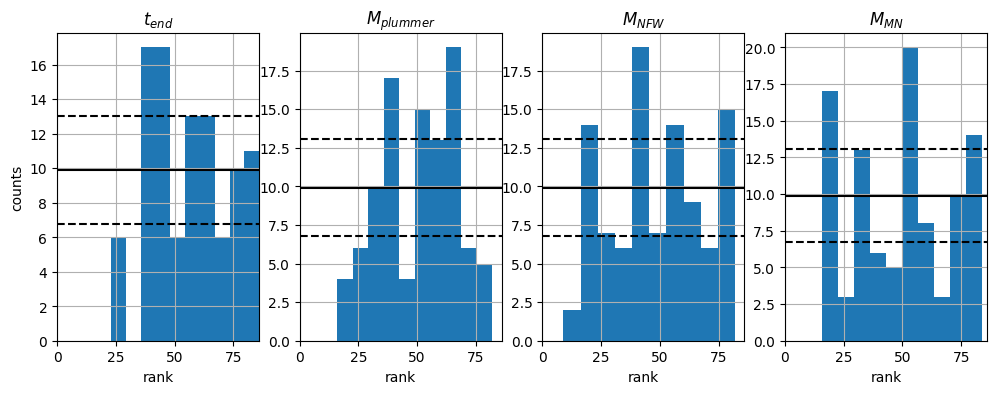

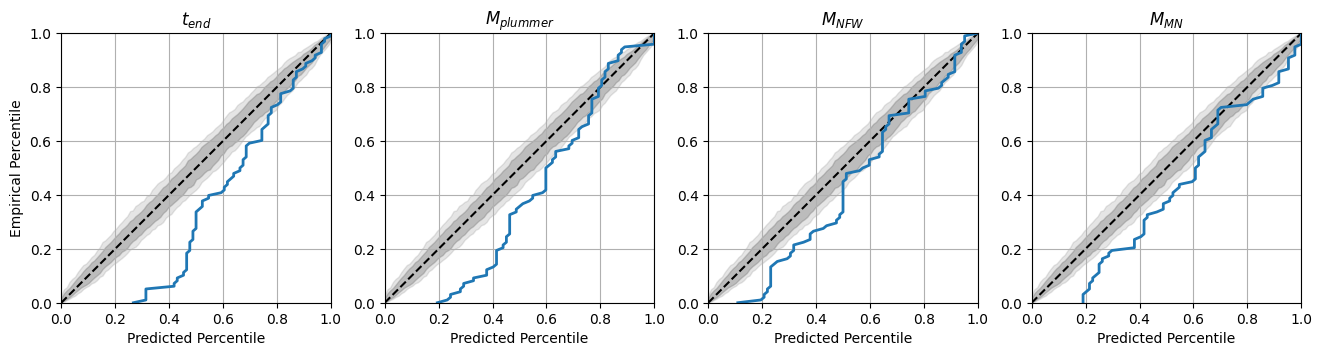

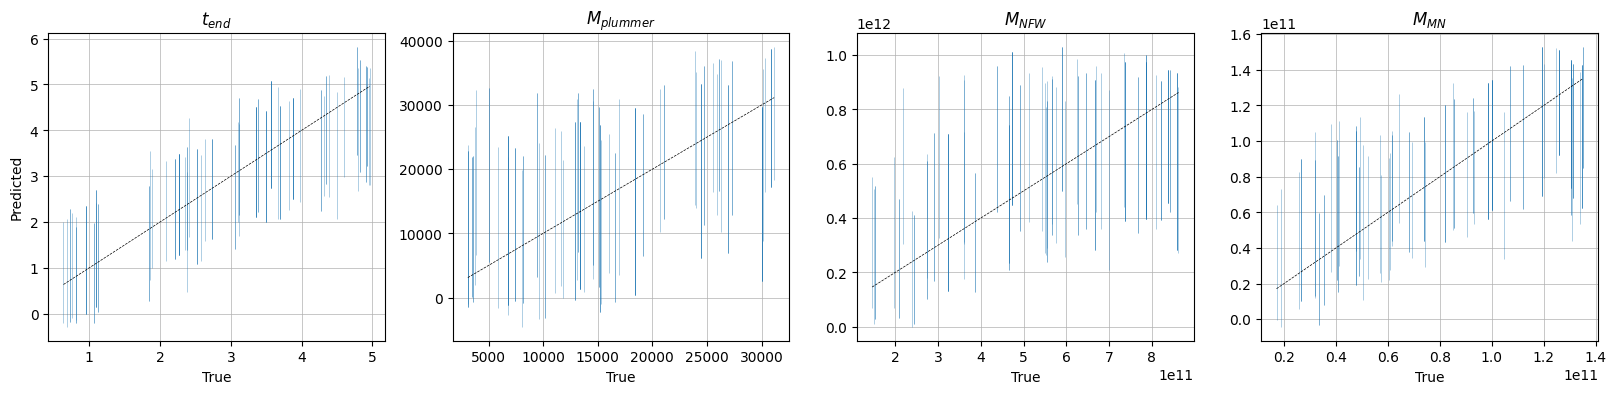

100%|██████████| 100/100 [00:00<00:00, 1008.14it/s]


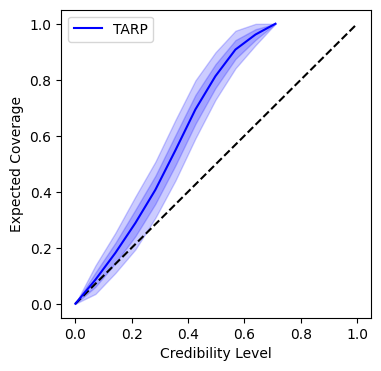

Plotting for n_observation: 198


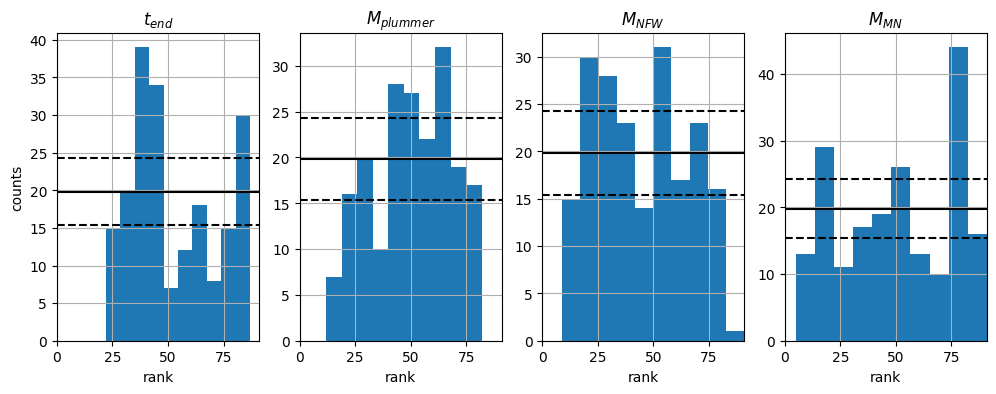

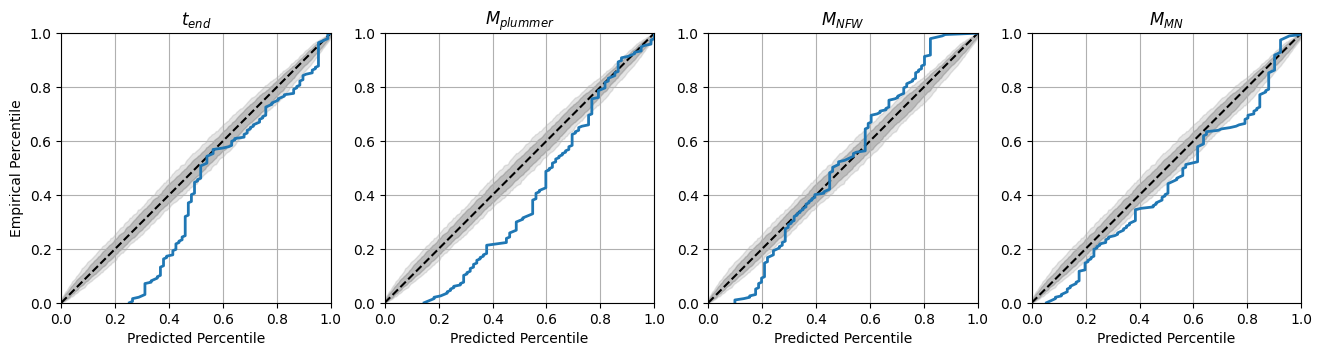

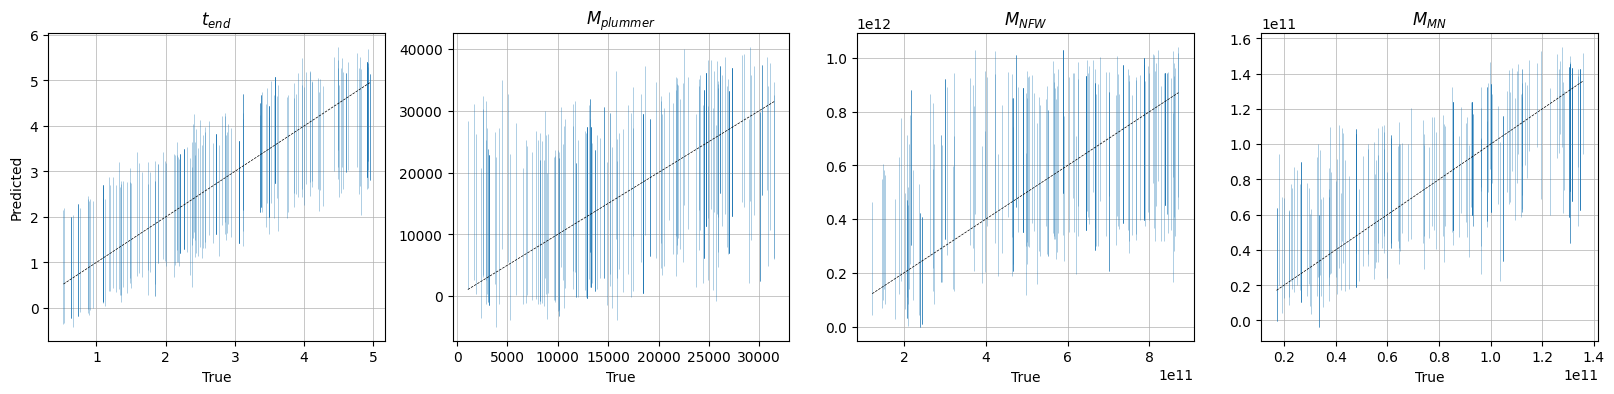

100%|██████████| 100/100 [00:00<00:00, 759.61it/s]


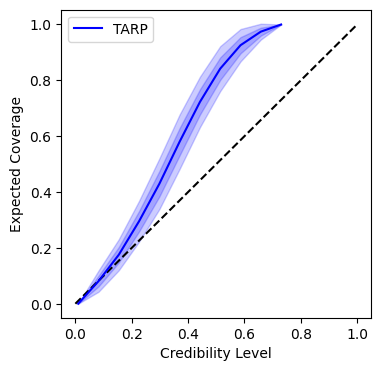

In [3]:
posterior_plots = PosteriorPlots(only_last=True)
posterior_plots()  # Call the instance to execute the plotting

In [4]:
savedir = './logs/OdisseoSimulatorFullAttentionAggregation/'
predicted_theta_test_set = np.load(f"{savedir}/pictures/predicted_theta_test_set_100.npz")['predicted_theta']
true_theta_test_set = np.load(f"{savedir}/pictures/predicted_theta_test_set_100.npz")['true_theta']

In [5]:
def filter_zero_observations(samples, trues):
    """
    Filter out observations where all samples are zero for all parameters.
    
    Args:
        samples: shape (n_samples, n_observations, 4)
        trues: shape (n_observations, 4) 
    
    Returns:
        filtered_samples, filtered_trues
    """
    # Check which observations have any non-zero values across all samples and parameters
    non_zero_mask = np.any(samples != 0, axis=(0, 2))  # Shape: (n_observations,)
    
    # Filter both arrays
    filtered_samples = samples[:, non_zero_mask, :]
    filtered_trues = trues[non_zero_mask, :]
    
    return filtered_samples, filtered_trues

filtered_samples, filtered_trues = filter_zero_observations(predicted_theta_test_set, true_theta_test_set)

In [6]:
filtered_samples.shape, filtered_trues.shape

((100, 99, 4), (99, 4))

# JUST PLOT 

In [ ]:
class PosteriorPlots():

    def __init__(self,  batch_size: int = 1_000, only_last: bool = True ):
        super().__init__()
        self.savedir = './logs/OdisseoSimulatorOT_AllParameters/'
        self.batch_size = batch_size
        self.labels = ['$t_{end}$', '$M_{plummer}$', '$M_{NFW}$', '$M_{MN}$']
        self.observation_idx = [i for i in range(100)]
        self.num_total_samples = 100
        self.only_last = only_last
        
    def __call__(self,):
        return self._call()

    def _call(self,  ):


        true_theta_test_set = np.zeros((len(self.observation_idx), 4))
        predicted_theta_test_set = np.zeros((self.num_total_samples, len(self.observation_idx), 4))

        old_true_theta_test_set = np.load(f"{self.savedir}/pictures/predicted_theta_test_set.npz")['true_theta']
        old_predicted_theta_test_set = np.load(f"{self.savedir}/pictures/predicted_theta_test_set.npz")['predicted_theta']

        print(f'Plotting for n_observation:', len(old_predicted_theta_test_set))

        rank_plot = self._plot_ranks_histogram(
                samples=old_predicted_theta_test_set,
                trues=old_true_theta_test_set,
                nbins=10)
        plt.show()
        
        coverage_plot = self._plot_coverage(
            samples=old_predicted_theta_test_set,
            trues=old_true_theta_test_set,
            plotscatter=True,
        )
        plt.show()

        prediction_plot = self._plot_predictions(
            samples=old_predicted_theta_test_set,
            trues=old_true_theta_test_set,
        )
        plt.show()

        tarp_plot = self._plot_TARP(
            posterior_samples=old_predicted_theta_test_set,
            theta=old_true_theta_test_set,
        )
        plt.show()
            

        predicted_theta_test_set = np.load(f"{self.savedir}/pictures/predicted_theta_test_set_100.npz")['predicted_theta']
        true_theta_test_set = np.load(f"{self.savedir}/pictures/predicted_theta_test_set_100.npz")['true_theta']

        predicted_theta_test_set, true_theta_test_set = self.filter_zero_observations(
            predicted_theta_test_set, true_theta_test_set
        )

        if self.only_last:

            old_predicted_theta_test_set = np.concatenate(
                [old_predicted_theta_test_set, predicted_theta_test_set], axis=1
            )
            old_true_theta_test_set = np.concatenate(
                [old_true_theta_test_set, true_theta_test_set], axis=0
            )

            print('Plotting for n_observation:', len(old_true_theta_test_set))

            rank_plot = self._plot_ranks_histogram(
                samples=old_predicted_theta_test_set,
                trues=old_true_theta_test_set,
                nbins=10)
            plt.show()
            
            coverage_plot = self._plot_coverage(
                samples=old_predicted_theta_test_set,
                trues=old_true_theta_test_set,
                plotscatter=True,
            )
            plt.show()

            prediction_plot = self._plot_predictions(
                samples=old_predicted_theta_test_set,
                trues=old_true_theta_test_set,
            )
            plt.show()

            tarp_plot = self._plot_TARP(
                posterior_samples=old_predicted_theta_test_set,
                theta=old_true_theta_test_set,
            )
            plt.show()


        else:
            for i in range(len(true_theta_test_set)):

                print(f'Plotting for n_observation:', len(old_predicted_theta_test_set)+i)

                old_predicted_theta_test_set = np.concatenate(
                    [old_predicted_theta_test_set, predicted_theta_test_set[:, :i]], axis=1
                )
                old_true_theta_test_set = np.concatenate(
                    [old_true_theta_test_set, true_theta_test_set[:i]], axis=0
                )
                

                rank_plot = self._plot_ranks_histogram(
                    samples=old_predicted_theta_test_set,
                    trues=old_true_theta_test_set,
                    nbins=10)
                plt.show()
                
                coverage_plot = self._plot_coverage(
                    samples=old_predicted_theta_test_set,
                    trues=old_true_theta_test_set,
                    plotscatter=True,
                )
                plt.show()

                prediction_plot = self._plot_predictions(
                    samples=old_predicted_theta_test_set,
                    trues=old_true_theta_test_set,
                )
                plt.show()

                tarp_plot = self._plot_TARP(
                    posterior_samples=old_predicted_theta_test_set,
                    theta=old_true_theta_test_set,
                )
                plt.show()
            
    
    def _get_ranks(
            self,
            samples: np.array,
            trues: np.array,
        ) -> np.array:
            """Get the marginal ranks of the true parameters in the posterior samples.

            Args:
                samples (np.array): posterior samples of shape (nsamples, ndata, npars)
                trues (np.array): true parameters of shape (ndata, npars)

            Returns:
                np.array: ranks of the true parameters in the posterior samples 
                    of shape (ndata, npars)
            """
            ranks = (samples < trues[None, ...]).sum(axis=0)
            return ranks


    def _plot_ranks_histogram(
            self, samples: np.ndarray, trues: np.ndarray, nbins: int = 10
        ) -> plt.Figure:
            """
            Plot a histogram of ranks for each parameter.

            Args:
                samples (numpy.ndarray): List of samples.
                trues (numpy.ndarray): Array of true values.
                signature (str): Signature for the histogram file name.
                nbins (int, optional): Number of bins for the histogram. Defaults to 10.

            Returns:
                matplotlib.figure.Figure: The generated figure.

            """
            ndata, npars = trues.shape
            navg = ndata / nbins
            ranks = self._get_ranks(samples, trues)

            fig, ax = plt.subplots(1, npars, figsize=(npars * 3, 4))
            if npars == 1:
                ax = [ax]

            for i in range(npars):
                ax[i].hist(np.array(ranks)[:, i], bins=nbins)
                ax[i].set_title(self.labels[i])
            ax[0].set_ylabel('counts')

            for axis in ax:
                axis.set_xlim(0, ranks.max())
                axis.set_xlabel('rank')
                axis.grid(visible=True)
                axis.axhline(navg, color='k')
                axis.axhline(navg - navg ** 0.5, color='k', ls="--")
                axis.axhline(navg + navg ** 0.5, color='k', ls="--")
            return fig

    def _plot_coverage(
            self, samples: np.ndarray, trues: np.ndarray, plotscatter: bool = True
        ) -> plt.Figure:
            """
            Plot the coverage of predicted percentiles against empirical percentiles.

            Args:
                samples (numpy.ndarray): Array of predicted samples.
                trues (numpy.ndarray): Array of true values.
                signature (str): Signature for the plot file name.
                plotscatter (bool, optional): Whether to plot the scatter plot. Defaults to True.

            Returns:
                matplotlib.figure.Figure: The generated figure.

            """
            ndata, npars = trues.shape
            ranks = self._get_ranks(samples, trues)

            unicov = [np.sort(np.random.uniform(0, 1, ndata)) for j in range(200)]
            unip = np.percentile(unicov, [5, 16, 84, 95], axis=0)

            fig, ax = plt.subplots(1, npars, figsize=(npars * 4, 4))
            if npars == 1:
                ax = [ax]
            cdf = np.linspace(0, 1, len(ranks))
            for i in range(npars):
                xr = np.sort(ranks[:, i])
                xr = xr / xr[-1]
                ax[i].plot(cdf, cdf, 'k--')
                if plotscatter:
                    ax[i].fill_between(cdf, unip[0], unip[-1],
                                    color='gray', alpha=0.2)
                    ax[i].fill_between(cdf, unip[1], unip[-2],
                                    color='gray', alpha=0.4)
                ax[i].plot(xr, cdf, lw=2, label='posterior')
                ax[i].set(adjustable='box', aspect='equal')
                ax[i].set_title(self.labels[i])
                ax[i].set_xlabel('Predicted Percentile')
                ax[i].set_xlim(0, 1)
                ax[i].set_ylim(0, 1)

            ax[0].set_ylabel('Empirical Percentile')
            for axis in ax:
                axis.grid(visible=True)
            return fig

    def _plot_predictions(
            self, samples: np.ndarray, trues: np.ndarray,
        ) -> plt.Figure:
            """
            Plot the mean and standard deviation of the predicted samples against
            the true values.

            Args:
                samples (np.ndarray): Array of predicted samples.
                trues (np.ndarray): Array of true values.
                signature (str): Signature for the plot.

            Returns:
                plt.Figure: The plotted figure.
            """
            npars = trues.shape[-1]
            mus, stds = samples.mean(axis=0), samples.std(axis=0)
            # print(f"mus shape: {mus.shape}, stds shape: {stds.shape}, trues shape: {trues.shape}")
            fig, axs = plt.subplots(1, npars, figsize=(npars * 5, 4))
            if npars == 1:
                axs = [axs]
            else:
                axs = axs.flatten()
            for j in range(npars):
                axs[j].errorbar(trues[:, j], mus[:, j], stds[:, j],
                                fmt="none", elinewidth=0.5, alpha=0.5)
                axs[j].plot(
                    *(2 * [np.linspace(min(trues[:, j]), max(trues[:, j]), 10)]),
                    'k--', ms=0.2, lw=0.5)
                axs[j].grid(which='both', lw=0.5)
                axs[j].set(adjustable='box', )
                axs[j].set_title(self.labels[j], fontsize=12)
                axs[j].set_xlabel('True')
            axs[0].set_ylabel('Predicted')

            return fig
    def _plot_TARP(
        self, posterior_samples: np.array, theta: np.array,
        references: str = "random", metric: str = "euclidean",
        bootstrap: Optional[bool] = True, norm: Optional[bool] = True,
        num_alpha_bins: Optional[int] = 10,
        num_bootstrap: Optional[int] = 100
    ) -> plt.Figure:
        """
        Plots the TARP credibility metric for the given posterior samples
        and theta values. See https://arxiv.org/abs/2302.03026 for details.

        Args:
            posterior_samples (np.array): Array of posterior samples.
            theta (np.array): Array of theta values.
            signature (str): Signature for the plot.
            references (str, optional): TARP reference type for TARP calculation. 
                Defaults to "random".
            metric (str, optional): TARP distance metric for TARP calculation. 
                Defaults to "euclidean".
            bootstrap (bool, optional): Whether to use bootstrapping for TARP error bars. 
                Defaults to False.
            norm (bool, optional): Whether to normalize the TARP metric. Defaults to True.
            num_alpha_bins (int, optional):number of bins to use for the TARP
                credibility values. Defaults to None.
            num_bootstrap (int, optional): Number of bootstrap iterations
                for TARP calculation. Defaults to 100.

        Returns:
            plt.Figure: The generated TARP plot.
        """
        ecp, alpha = tarp.get_tarp_coverage(
            posterior_samples, theta,
            references=references, metric=metric,
            norm=norm, bootstrap=bootstrap,
            num_alpha_bins=num_alpha_bins,
            num_bootstrap=num_bootstrap
        )

        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        ax.plot([0, 1], [0, 1], ls='--', color='k')
        if bootstrap:
            ecp_mean = np.mean(ecp, axis=0)
            ecp_std = np.std(ecp, axis=0)
            ax.plot(alpha, ecp_mean, label='TARP', color='b')
            ax.fill_between(alpha, ecp_mean - ecp_std, ecp_mean + ecp_std,
                            alpha=0.2, color='b')
            ax.fill_between(alpha, ecp_mean - 2 * ecp_std, ecp_mean + 2 * ecp_std,
                            alpha=0.2, color='b')
        else:
            ax.plot(alpha, ecp, label='TARP')
        ax.legend()
        ax.set_ylabel("Expected Coverage")
        ax.set_xlabel("Credibility Level")

        return fig
    
    def filter_zero_observations(self, samples, trues):
        """
        Filter out observations where all samples are zero for all parameters.
        
        Args:
            samples: shape (n_samples, n_observations, 4)
            trues: shape (n_observations, 4) 
        
        Returns:
            filtered_samples, filtered_trues
        """
        # Check which observations have any non-zero values across all samples and parameters
        non_zero_mask = np.any(samples != 0, axis=(0, 2))  # Shape: (n_observations,)
        
        # Filter both arrays
        filtered_samples = samples[:, non_zero_mask, :]
        filtered_trues = trues[non_zero_mask, :]
        return filtered_samples, filtered_trues